In [2]:
# 1. Date Feature Engineering 
import pandas as pd

# Load dataset
df = pd.read_csv("../data/q3_retail_promotions.csv")

# Convert transaction_date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract year
df['year'] = df['transaction_date'].dt.year

# Extract month
df['month'] = df['transaction_date'].dt.month

# Extract day of week (0 = Monday, 6 = Sunday)
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create is_month_end feature
# If day >= 25 → 1, else 0
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [3]:
# 2. Temporal Train-Test Split
# Step 1: Sort by date
df = df.sort_values(by='transaction_date')

# Step 2: Create split index (80%)
split_index = int(len(df) * 0.8)

# Step 3: Split data
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

# Check sizes
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (960, 13)
Test shape: (240, 13)


Temporal Train-Test Split

The dataset was first sorted by transaction_date to preserve the chronological order of transactions. The earliest 80% of the data was used as the training set, and the most recent 20% was used as the test set.

A random split is inappropriate for time-ordered data because it can lead to data leakage, where information from the future is unintentionally used during training. This results in overly optimistic model performance that does not reflect real-world scenarios.

In practice, models are trained on past data to predict future outcomes, so maintaining temporal order ensures a more realistic and reliable evaluation.

Temporal splitting simulates real-world deployment conditions where only historical data is available at prediction time.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

# Split features and target
X_train = train_df.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test_df['items_sold']

# Define columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Fit & Transform
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

# Feature names
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Convert to DataFrame (important for readability)
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

# Output check
print("Processed Train Shape:", X_train_processed.shape)
print("Processed Test Shape:", X_test_processed.shape)

X_train_df.head()

Processed Train Shape: (960, 13)
Processed Test Shape: (240, 13)


,cat__promotion_type_category_offer,cat__promotion_type_flat_discount,cat__promotion_type_free_gift,cat__promotion_type_loyalty_points,cat__location_type_semi-urban,cat__location_type_urban,cat__store_size_medium,cat__store_size_small,num__store_id,num__is_weekend,num__is_festival,num__competition_density,num__is_month_end
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.199960,1.590412,-0.361583,0.042569,-0.506502
1,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-1.398564,1.590412,2.765619,-1.443485,-0.506502
2,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,-0.842555,1.590412,-0.361583,0.414083,-0.506502
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,-0.564551,1.590412,-0.361583,0.785596,-0.506502
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.728983,-0.628768,-0.361583,-0.700458,-0.506502


Preprocessing Pipeline

A preprocessing pipeline was built using ColumnTransformer to apply appropriate transformations to different feature types.

Categorical features (promotion_type, location_type, store_size) were transformed using One-Hot Encoding, converting them into numerical format suitable for machine learning models.
Numerical features were scaled using StandardScaler to normalize their distributions and ensure equal contribution during model training.

The pipeline was integrated using Pipeline for reproducibility and consistency.

Importantly, the pipeline was fit only on the training data and then applied to the test data. This prevents data leakage and ensures that the model evaluation reflects real-world performance, where future data is not available during training.

After preprocessing, the feature space expanded due to one-hot encoding of categorical variables. The transformed dataset is now fully numerical and suitable for regression modeling.

In [10]:
# 4. Model Training and Evaluation

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Linear Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Fit models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [11]:

y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"\n{model_name}")
    print("MAE:", round(mae, 2))
    print("RMSE:", round(rmse, 2))

# Evaluate both
evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")


Linear Regression
MAE: 21.01
RMSE: 27.11

Random Forest
MAE: 24.86
RMSE: 31.24


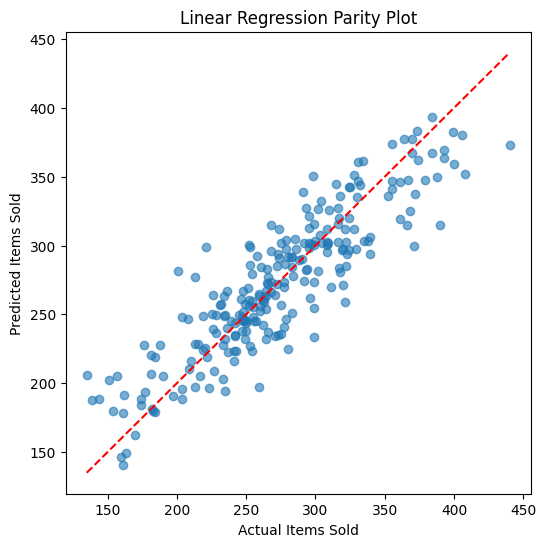

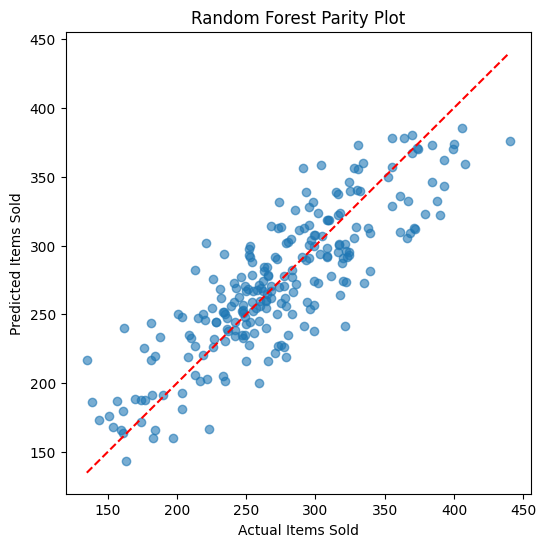

In [13]:
# parity Plot

import matplotlib.pyplot as plt

def parity_plot(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    
    # Diagonal line
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--')
    
    plt.xlabel("Actual Items Sold")
    plt.ylabel("Predicted Items Sold")
    plt.title(title)
    plt.show()

# Plot for both models
parity_plot(y_test, y_pred_lr, "Linear Regression Parity Plot")
parity_plot(y_test, y_pred_rf, "Random Forest Parity Plot")

In [14]:
# Get feature names
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get importances
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create DataFrame
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(10)

,feature,importance
7,cat__store_size_small,0.184641
10,num__is_festival,0.174852
5,cat__location_type_urban,0.140985
9,num__is_weekend,0.132004
8,num__store_id,0.098494
11,num__competition_density,0.072479
6,cat__store_size_medium,0.059104
4,cat__location_type_semi-urban,0.040317
3,cat__promotion_type_loyalty_points,0.034768
0,cat__promotion_type_category_offer,0.021639


In [15]:
top5 = feat_imp.head(5)
top5

,feature,importance
7,cat__store_size_small,0.184641
10,num__is_festival,0.174852
5,cat__location_type_urban,0.140985
9,num__is_weekend,0.132004
8,num__store_id,0.098494
